# IDC Backtesting and Advanced Metrics

This notebook introduces two topics that build on the basics covered in the DA walkthrough:

1. **Intraday Continuous (IDC) trading** — how to backtest against a live-style order book, where orders match throughout the day rather than in a single daily auction
2. **Advanced metrics** — the equity curve, Sharpe ratio, maximum drawdown, and the other numbers that tell you whether a strategy is *good* rather than just *lucky*

No prior knowledge of power markets is assumed. Every piece of jargon is explained the first time it appears.

---

**What you'll learn**
- The difference between a DA auction and IDC continuous trading
- How to read and visualise IDC order book event data
- How to write an IDC algo using the `on_bar` hook
- What an equity curve is and why it matters more than total PnL
- Sharpe ratio, max drawdown, and profit factor — without the maths degree
- How to export a backtest report to HTML, JSON, and Parquet

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")  # suppress minor deprecation warnings in the tutorial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import date, timedelta
from decimal import Decimal

# Data directories — both are relative to this examples/ directory
FIXTURES_DIR = Path("../tests/fixtures")
IDC_DATA_DIR = FIXTURES_DIR / "nordpool"   # contains idc_events/NO1_2026_03.parquet
DA_DATA_DIR  = FIXTURES_DIR               # contains da_prices.parquet

print("Fixture directories:")
print(f"  IDC: {IDC_DATA_DIR.resolve()}")
print(f"  DA:  {DA_DATA_DIR.resolve()}")
print("\nAll paths exist:", IDC_DATA_DIR.exists() and DA_DATA_DIR.exists())

Fixture directories:
  IDC: /Users/tommedhurst/Source/GitHub/nexa-backtest/tests/fixtures/nordpool
  DA:  /Users/tommedhurst/Source/GitHub/nexa-backtest/tests/fixtures

All paths exist: True


---

## Part 1: Intraday Continuous (IDC) Backtesting

### 1.1 DA vs IDC — Two Very Different Markets

In the previous walkthrough we covered **Day-Ahead (DA) auctions**. Here's a quick recap of how they differ from IDC:

| | Day-Ahead Auction | Intraday Continuous |
|---|---|---|
| **When does matching happen?** | Once, at gate closure (typically D-1 12:00) | Continuously throughout the day |
| **Price** | All participants get the same clearing price | You fill at the resting order's price |
| **Order book?** | No — just a single clearing price | Yes — a full bid/ask book per product |
| **Gate closure** | Once per delivery day | Per product, typically 30 min before delivery |
| **Data volume** | Small (~1.7 MB/zone/year) | Large (~10 GB/zone/year) |

Think of a **DA auction** as a sealed-bid tender: everyone submits bids before a deadline, and the auctioneer picks the price that clears the market. You don't know what anyone else bid.

Think of **IDC** as a stock exchange: there's a live order book showing all resting buy and sell orders. When your buy order price meets a resting sell order's price, the trade happens immediately — no waiting for a deadline.

### The product naming convention

In IDC, each 15-minute delivery period is a separate product:
- `NO1-QH-0800` = the 08:00–08:15 delivery window for the NO1 (Norway South) bidding zone
- `NO1-QH-0815` = 08:15–08:30
- `NO1-QH-0830` = 08:30–08:45

`QH` stands for Quarter-Hour (15-minute MTU). All three trade simultaneously, right up to their respective gate closure times.

### 1.2 Exploring IDC Event Data

IDC data is stored as a stream of **order book events** — every new order, modification, cancellation, and trade that happened on the exchange. The backtester replays these events in timestamp order to reconstruct what the market looked like at any point in time.

Let's load the fixture data and see what it looks like.

In [2]:
# Load the IDC fixture: 1 day of synthetic Nord Pool data for NO1
idc_events = pd.read_parquet(IDC_DATA_DIR / "idc_events" / "NO1_2026_03.parquet")

print(f"Shape: {idc_events.shape}")
print(f"\nColumns: {list(idc_events.columns)}")
print(f"\nDate range: {idc_events['timestamp'].min()} to {idc_events['timestamp'].max()}")
print(f"\nProducts: {sorted(idc_events['product_id'].unique())}")
print(f"\nEvent type breakdown:")
print(idc_events['event_type'].value_counts().to_string())
print(f"\nPrice range: {idc_events['price_eur_mwh'].min():.2f} – {idc_events['price_eur_mwh'].max():.2f} EUR/MWh")
print(f"\nFirst few rows:")
idc_events.head(6)

Shape: (3600, 11)

Columns: ['timestamp', 'event_type', 'order_id', 'zone', 'product_id', 'side', 'price_eur_mwh', 'volume_mw', 'remaining_mw', 'aggressor_side', 'trade_id']

Date range: 2026-03-01 00:00:00+00:00 to 2026-03-01 23:58:48+00:00

Products: ['NO1-QH-0800', 'NO1-QH-0815', 'NO1-QH-0830']

Event type breakdown:
event_type
new       1775
trade     1091
cancel     734

Price range: 44.70 – 57.40 EUR/MWh

First few rows:


,timestamp,event_type,order_id,zone,product_id,side,price_eur_mwh,volume_mw,remaining_mw,aggressor_side,trade_id
0,2026-03-01 00:00:00+00:00,new,e48ef740-8b65-4345-9413-22fe56e2e513,NO1,NO1-QH-0800,sell,52.2,7.300000,7.300000,NaN,NaN
1,2026-03-01 00:00:00+00:00,new,bfc563a1-3c8a-4605-bfd7-81e3cc8c9589,NO1,NO1-QH-0815,buy,48.8,10.400000,10.400000,NaN,NaN
2,2026-03-01 00:00:00+00:00,new,5bbca905-b318-48bb-8579-c6d0321ca08b,NO1,NO1-QH-0830,sell,51.8,2.200000,2.200000,NaN,NaN
3,2026-03-01 00:01:12+00:00,new,ab5d5c96-2397-4648-b571-ddb5c4efcf40,NO1,NO1-QH-0800,buy,49.2,0.500000,0.500000,NaN,NaN
4,2026-03-01 00:01:12+00:00,new,8249a1da-7084-4d96-be71-2cc9609669d1,NO1,NO1-QH-0815,buy,49.5,2.700000,2.700000,NaN,NaN
5,2026-03-01 00:01:12+00:00,trade,5bbca905-b318-48bb-8579-c6d0321ca08b,NO1,NO1-QH-0830,sell,51.8,1.070819,1.129181,buy,70bea379-d642-46f1-b402-00fba40a0bdf


Each row is one **market event**. The columns mean:

| Column | Meaning |
|---|---|
| `timestamp` | When the event occurred on the exchange |
| `event_type` | `new` = new order placed, `cancel` = order withdrawn, `trade` = a trade happened |
| `order_id` | Unique ID of the order this event relates to |
| `product_id` | Which 15-min delivery period (e.g. `NO1-QH-0800`) |
| `side` | `buy` = bid side, `sell` = ask side |
| `price_eur_mwh` | Order or trade price |
| `volume_mw` | Original order size in megawatts |
| `remaining_mw` | How much volume is still available (shrinks as orders are partially filled) |
| `aggressor_side` | For trades: who was the aggressor (crossed to the other side). `None` = not available |
| `trade_id` | Unique ID for trade events, `None` for non-trade events |

**Reconstructing the order book:** If you start with an empty book and replay all `new`, `cancel`, and order-`trade` events in order, you can always know exactly which orders are resting at any point in time. This is what the matching engine does internally.

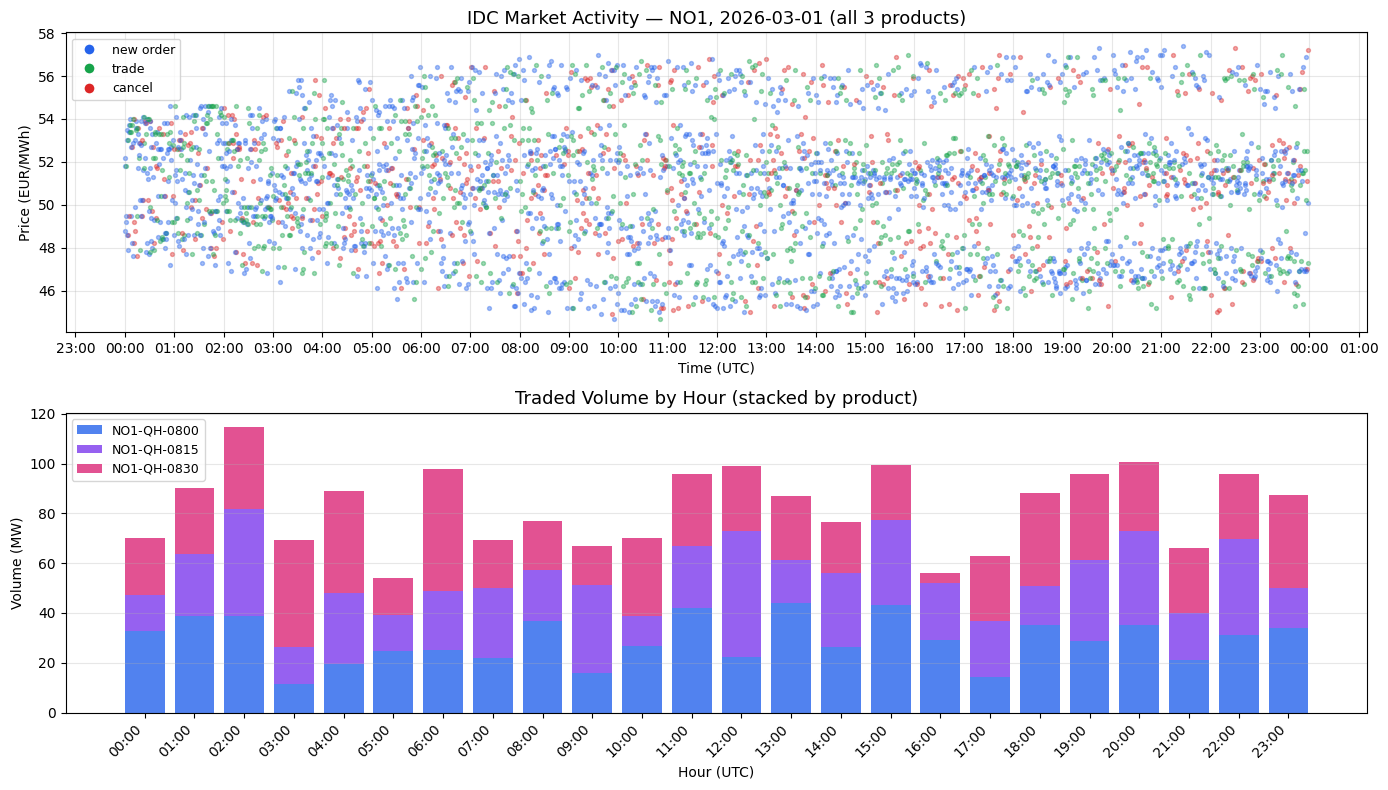


Total trades: 1091
Total volume traded: 1979.1 MW

Note: gate closures at 07:30, 07:45, 08:00 UTC — trading stops before delivery


In [3]:
# Visualise: what does the stream of market activity look like over the day?

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

colors = {"new": "#2563eb", "trade": "#16a34a", "cancel": "#dc2626"}

# --- Panel 1: all events across the day, coloured by type ---
ax1 = axes[0]
for product, group in idc_events.groupby("product_id"):
    for etype, egroup in group.groupby("event_type"):
        ax1.scatter(
            egroup["timestamp"], egroup["price_eur_mwh"],
            c=colors.get(etype, "grey"), alpha=0.4, s=8, label=f"{product} {etype}"
        )

# Create a clean legend — one entry per event type only
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors["new"],    markersize=8, label="new order"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors["trade"],  markersize=8, label="trade"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors["cancel"], markersize=8, label="cancel"),
]
ax1.legend(handles=legend_elements, fontsize=9)
ax1.set_title("IDC Market Activity — NO1, 2026-03-01 (all 3 products)", fontsize=13)
ax1.set_ylabel("Price (EUR/MWh)")
ax1.set_xlabel("Time (UTC)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.grid(True, alpha=0.3)

# --- Panel 2: trade volume over time ---
ax2 = axes[1]
trades = idc_events[idc_events["event_type"] == "trade"].copy()
trades["hour"] = trades["timestamp"].dt.floor("1h")
hourly_vol = trades.groupby(["hour", "product_id"])["volume_mw"].sum().unstack(fill_value=0)

bottom = np.zeros(len(hourly_vol))
product_colors = {"NO1-QH-0800": "#2563eb", "NO1-QH-0815": "#7c3aed", "NO1-QH-0830": "#db2777"}
for product_id in hourly_vol.columns:
    ax2.bar(
        range(len(hourly_vol)),
        hourly_vol[product_id].values,
        bottom=bottom,
        label=product_id,
        color=product_colors.get(product_id, "grey"),
        alpha=0.8,
    )
    bottom += hourly_vol[product_id].values

ax2.set_title("Traded Volume by Hour (stacked by product)", fontsize=13)
ax2.set_ylabel("Volume (MW)")
ax2.set_xlabel("Hour (UTC)")
ax2.set_xticks(range(len(hourly_vol)))
ax2.set_xticklabels([t.strftime("%H:00") for t in hourly_vol.index], rotation=45, ha="right")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nTotal trades: {len(trades)}")
print(f"Total volume traded: {trades['volume_mw'].sum():.1f} MW")
print(f"\nNote: gate closures at 07:30, 07:45, 08:00 UTC — trading stops before delivery")

The chart shows a key feature of IDC: trading happens continuously from midnight all the way up to gate closure (30 minutes before delivery). After gate closure, no new orders can be submitted for that product — whatever position you have is what you deliver.

### 1.3 The Order Book — A Live Snapshot

At any moment, the order book for a product looks like this:

```
  BIDS (buyers)          ASKS (sellers)
  Price  Volume          Price  Volume
  50.80  5.2 MW    ←→    51.10  7.3 MW   ← best ask
  50.50  8.0 MW          51.50  3.1 MW
  50.20  12.5 MW         52.00  4.0 MW
    ...                    ...
```

The **spread** is `best_ask - best_bid = 51.10 - 50.80 = 0.30 EUR/MWh`. Tighter spreads mean more liquid markets.

If you place a **buy at 51.10 or above**, it fills immediately at the ask price. If you place a **buy at 50.80 or below**, it rests on the bid side and waits for a seller to come down to your price.

Let's visualise the order book state at the start of the day:

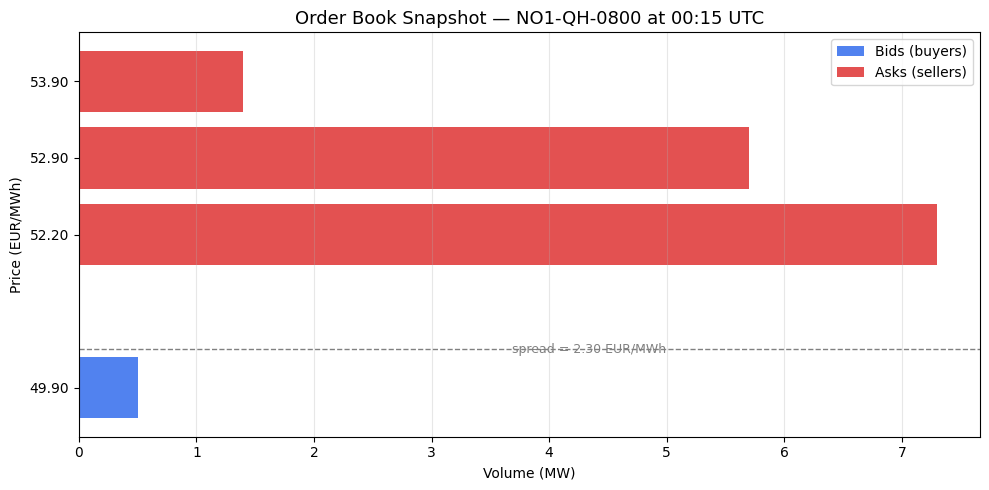

Best bid: 49.90 EUR/MWh  (0.50 MW available)
Best ask: 52.20 EUR/MWh  (7.30 MW available)
Mid price: 51.05 EUR/MWh
Spread: 2.30 EUR/MWh


In [4]:
# Reconstruct the order book for NO1-QH-0800 at 00:15 UTC
# (after the first 15 minutes of trading)

product = "NO1-QH-0800"
snapshot_time = pd.Timestamp("2026-03-01 00:15:00", tz="UTC")

# Replay events up to the snapshot time
events_so_far = idc_events[
    (idc_events["product_id"] == product) &
    (idc_events["timestamp"] <= snapshot_time)
].sort_values("timestamp")

book = {}  # order_id → {side, price, remaining_mw}
for _, row in events_so_far.iterrows():
    oid = row["order_id"]
    if row["event_type"] == "new":
        book[oid] = {"side": row["side"], "price": row["price_eur_mwh"], "remaining": row["remaining_mw"]}
    elif row["event_type"] == "cancel" and oid in book:
        del book[oid]
    elif row["event_type"] in ("trade",) and oid in book:
        book[oid]["remaining"] = row["remaining_mw"]
        if row["remaining_mw"] <= 0:
            del book[oid]

# Aggregate by price level
import collections
bids = collections.defaultdict(float)
asks = collections.defaultdict(float)
for order in book.values():
    if order["remaining"] > 0:
        if order["side"] == "buy":
            bids[order["price"]] += order["remaining"]
        else:
            asks[order["price"]] += order["remaining"]

bid_prices = sorted(bids.keys(), reverse=True)[:8]   # best 8 bids
ask_prices = sorted(asks.keys())[:8]                  # best 8 asks

fig, ax = plt.subplots(figsize=(10, 5))

# Plot bids (horizontal bars, left side, blue)
bid_volumes = [bids[p] for p in bid_prices]
bid_positions = range(len(bid_prices))
ax.barh(bid_positions, bid_volumes, color="#2563eb", alpha=0.8, label="Bids (buyers)")
ax.set_yticks(list(bid_positions))
ax.set_yticklabels([f"{p:.2f}" for p in bid_prices])

# Overlay asks on same chart (right side, red)
ask_volumes = [asks[p] for p in ask_prices]
offset = len(bid_prices) + 1  # leave a gap between bids and asks
ask_positions = range(offset, offset + len(ask_prices))
ax.barh(list(ask_positions), ask_volumes, color="#dc2626", alpha=0.8, label="Asks (sellers)")
ax.set_yticks(list(bid_positions) + list(ask_positions))
ax.set_yticklabels(
    [f"{p:.2f}" for p in bid_prices] + [f"{p:.2f}" for p in ask_prices]
)

# Spread marker
if bid_prices and ask_prices:
    best_bid = bid_prices[0]
    best_ask = ask_prices[0]
    ax.axhline(y=len(bid_prices) - 0.5, color="grey", linestyle="--", linewidth=1)
    ax.text(
        max(bid_volumes + ask_volumes) * 0.5,
        len(bid_prices) - 0.5,
        f" spread = {best_ask - best_bid:.2f} EUR/MWh",
        va="center", color="grey", fontsize=9
    )

ax.set_xlabel("Volume (MW)")
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title(f"Order Book Snapshot — {product} at {snapshot_time.strftime('%H:%M UTC')}", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

if bid_prices and ask_prices:
    print(f"Best bid: {bid_prices[0]:.2f} EUR/MWh  ({bids[bid_prices[0]]:.2f} MW available)")
    print(f"Best ask: {ask_prices[0]:.2f} EUR/MWh  ({asks[ask_prices[0]]:.2f} MW available)")
    print(f"Mid price: {(bid_prices[0] + ask_prices[0]) / 2:.2f} EUR/MWh")
    print(f"Spread: {ask_prices[0] - bid_prices[0]:.2f} EUR/MWh")

### 1.4 How IDC Matching Works

The backtester uses **historical replay matching**: it replays the real exchange's order flow and checks whether your algo's orders would have matched against the historical book.

The rules:
1. When you place a **buy at price X**, the engine checks the historical ask side. If there's a historical seller at price ≤ X, you fill at *their* price (not yours). You're the aggressor, they're the resting order.
2. If no match exists, your order **rests** in the book. When a historical sell event arrives later at a price ≤ your bid, you fill at that price.
3. **Price-taker assumption**: your orders don't affect the historical order flow. If a historical trade happened at 51.10 and you had a resting buy at 51.10, both fills are assumed to happen independently. This is reasonable for small volumes relative to market size.

Let's demonstrate this directly using the `ContinuousMatchingEngine`:

In [5]:
from datetime import datetime, timezone
from nexa_backtest.engines.matching import ContinuousMatchingEngine
from nexa_backtest.types import Order, MarketDataUpdate, HistoricalTrade, Side

engine = ContinuousMatchingEngine()
ts = datetime(2026, 3, 1, 9, 0, tzinfo=timezone.utc)

product = "NO1-QH-0900"

# --- Step 1: A historical seller places a resting ask at 51.50 ---
historical_ask = MarketDataUpdate(
    timestamp=ts,
    product_id=product,
    event_type="new",
    order_id="hist-sell-001",
    side="sell",
    price_eur_mwh=Decimal("51.50"),
    volume_mw=Decimal("10.0"),
    remaining_mw=Decimal("10.0"),
)
fills = engine.process_historical_event(historical_ask)
print("Step 1: Historical seller places ask at 51.50 EUR/MWh")
print(f"  Fills generated: {len(fills)} (no algo order resting yet)")

# --- Step 2: Algo places an aggressive buy at 52.00 (above the ask) ---
print("\nStep 2: Algo places BUY at 52.00 EUR/MWh (above the 51.50 ask)")
order_aggressive = Order.buy(product, volume_mw=5.0, price_eur_mwh=52.00)
fills = engine.place_algo_order(order_aggressive, ts)
print(f"  Fills: {len(fills)}")
if fills:
    print(f"  Fill price: {fills[0].price} EUR/MWh  ← resting ask price, not our bid!")
    print(f"  Fill volume: {fills[0].volume} MW")

# --- Step 3: Algo places a passive buy BELOW the ask — it rests ---
print("\nStep 3: Algo places BUY at 50.00 EUR/MWh (below the ask — rests in book)")
order_passive = Order.buy(product, volume_mw=3.0, price_eur_mwh=50.00)
fills = engine.place_algo_order(order_passive, ts)
print(f"  Immediate fills: {len(fills)} (order is resting, waiting for a seller)")
print(f"  Resting algo orders: {engine.get_resting_algo_order_ids()}")

# --- Step 4: Historical aggressive seller comes in at 49.80 — hits our resting buy ---
print("\nStep 4: Historical TRADE at 49.80 EUR/MWh with aggressor_side='sell'")
historical_trade = HistoricalTrade(
    timestamp=ts + timedelta(minutes=3),
    product_id=product,
    trade_id="trade-001",
    price_eur_mwh=Decimal("49.80"),
    volume_mw=Decimal("5.0"),
    aggressor_side="sell",  # a seller crossed the spread to hit resting bids
)
fills = engine.process_historical_event(historical_trade)
print(f"  Fills: {len(fills)}")
if fills:
    print(f"  Fill price: {fills[0].price} EUR/MWh  ← trade price (the aggressor's price)")
    print(f"  Fill volume: {fills[0].volume} MW")
    print("  Our resting buy at 50.00 was hit by a seller coming in at 49.80 ✓")

Step 1: Historical seller places ask at 51.50 EUR/MWh
  Fills generated: 0 (no algo order resting yet)

Step 2: Algo places BUY at 52.00 EUR/MWh (above the 51.50 ask)
  Fills: 1
  Fill price: 51.50 EUR/MWh  ← resting ask price, not our bid!
  Fill volume: 5.0 MW

Step 3: Algo places BUY at 50.00 EUR/MWh (below the ask — rests in book)
  Immediate fills: 0 (order is resting, waiting for a seller)
  Resting algo orders: ['80329ae1-d866-4489-8d93-7071ba3f4c5a']

Step 4: Historical TRADE at 49.80 EUR/MWh with aggressor_side='sell'
  Fills: 1
  Fill price: 49.80 EUR/MWh  ← trade price (the aggressor's price)
  Fill volume: 3.0 MW
  Our resting buy at 50.00 was hit by a seller coming in at 49.80 ✓


Key observations:
- When **you're the aggressor** (buying at or above the ask), you fill at the ask's price — never your own price
- When **you're the resting order** (buying below the current ask), you get filled when a historical seller crosses down to your price
- The fill price is always determined by the **resting order's price** (the price-time priority rule)

This is the same rule used by all electronic exchanges: if you want immediacy, you pay the spread.

### 1.5 Writing an IDC Algo

IDC algos use the `on_bar` hook instead of `on_auction_open`. `on_bar` is called at every 15-minute MTU boundary — 96 times per day. From within `on_bar`, you can:
- Read the live order book: `ctx.get_orderbook(product_id)`, `ctx.get_best_bid(...)`, `ctx.get_best_ask(...)`
- Check how long until gate closure: `ctx.time_to_gate_closure(product_id)`
- Place or cancel orders: `ctx.place_order(...)`, `ctx.cancel_order(...)`

Here's a simple IDC algo that buys at the best ask for each active product — an aggressive strategy that always fills immediately:

In [6]:
from nexa_backtest import SimpleAlgo, Order, BacktestEngine
from nexa_backtest.context import TradingContext
from nexa_backtest.types import Fill


class BestAskBuyerAlgo(SimpleAlgo):
    """Buys 1 MW at the best ask price every bar, for each IDC product.

    This is an aggressive strategy — it always crosses the spread to fill
    immediately. It doesn't care about price; it just wants to trade.
    In practice this is a poor strategy (you always pay the ask), but it
    demonstrates the IDC mechanics clearly.
    """

    # Products to trade — the three QH products available in the fixture
    PRODUCTS = ["NO1-QH-0800", "NO1-QH-0815", "NO1-QH-0830"]

    def on_setup(self, ctx: TradingContext) -> None:
        self.fill_count = 0
        self.gate_closures_seen: list[str] = []
        ctx.log("BestAskBuyerAlgo started")

    def on_bar(self, ctx: TradingContext) -> None:
        """Called every 15 minutes — evaluate and trade."""
        for product_id in self.PRODUCTS:
            # Don't place orders when gate is closing in < 5 minutes
            ttg = ctx.time_to_gate_closure(product_id)
            if ttg.total_seconds() < 300:
                continue

            # Check current best ask for this product
            ask = ctx.get_best_ask(product_id)
            if ask is None:
                # No sellers in the book yet — skip
                continue

            # Place a buy 1 EUR above the ask to guarantee an immediate fill.
            # (In practice you'd bid exactly at the ask, but adding 1 EUR
            # makes the match absolutely certain even if the book updates.)
            order = Order.buy(
                product_id=product_id,
                volume_mw=1.0,
                price_eur_mwh=float(ask.price) + 1.0,
            )
            ctx.place_order(order)

    def on_fill(self, ctx: TradingContext, fill: Fill) -> None:
        self.fill_count += 1

    def on_gate_closure(self, ctx: TradingContext, product_id: str) -> None:
        """Called when trading closes for a product — no more orders allowed."""
        self.gate_closures_seen.append(product_id)
        ctx.log(f"Gate closed for {product_id} — {len(self.gate_closures_seen)} products closed so far")

    def on_teardown(self, ctx: TradingContext) -> None:
        ctx.log(f"Backtest done. Total fills: {self.fill_count}")
        ctx.log(f"Gate closures seen: {self.gate_closures_seen}")


print("BestAskBuyerAlgo defined.")
print("\nKey design choices:")
print("  • on_bar is called every 15 minutes")
print("  • ctx.get_best_ask() reads the live historical order book")
print("  • ctx.time_to_gate_closure() prevents orders near gate close")
print("  • on_gate_closure() fires when each product's gate closes")

BestAskBuyerAlgo defined.

Key design choices:
  • on_bar is called every 15 minutes
  • ctx.get_best_ask() reads the live historical order book
  • ctx.time_to_gate_closure() prevents orders near gate close
  • on_gate_closure() fires when each product's gate closes


### 1.6 Running the IDC Backtest

In [7]:
# Run the IDC backtest — 1 day (the only day in our fixture)
idc_engine = BacktestEngine(
    algo=BestAskBuyerAlgo(),
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 1),
    products=["NO1-QH"],            # "NO1-QH" means: all QH products for zone NO1
    data_dir=IDC_DATA_DIR,          # points to the directory containing idc_events/
    capital=Decimal("100000"),
)

print("Running IDC backtest...")
idc_result = idc_engine.run()
print(f"Done!\n")

print(f"Total fills:       {len(idc_result.fills)}")
print(f"Equity snapshots:  {len(idc_result.equity_curve)}")
print(f"Products traded:   {sorted(set(f.product_id for f in idc_result.fills))}")

# Show a few fills
fills_df = idc_result.trades_df()
print(f"\nFirst 6 fills:")
fills_df.head(6)

Running IDC backtest...


Done!

Total fills:       122
Equity snapshots:  32
Products traded:   ['NO1-QH-0800', 'NO1-QH-0815', 'NO1-QH-0830']

First 6 fills:


,timestamp,product_id,side,price,volume,order_id
0,2026-03-01 00:00:00+00:00,NO1-QH-0800,BUY,52.2,1.0,b34ca1c0-b54d-46f2-8501-120ebfd32ce9
1,2026-03-01 00:00:00+00:00,NO1-QH-0815,BUY,53.6,1.0,37031ff2-4495-46c1-9771-26f1e541e97b
2,2026-03-01 00:00:00+00:00,NO1-QH-0830,BUY,51.8,1.0,bc5444f0-d6d7-4f40-ba2a-251480de1908
3,2026-03-01 00:15:00+00:00,NO1-QH-0800,BUY,52.2,1.0,56d0d8e1-2b11-425a-a176-f37ff16a35ae
4,2026-03-01 00:15:00+00:00,NO1-QH-0815,BUY,54.0,1.0,92367f3c-842e-4bd4-9869-e1f29be49f6e
5,2026-03-01 00:15:00+00:00,NO1-QH-0830,BUY,51.2,1.0,6bb7d476-29aa-40df-9c95-d40c800d7227


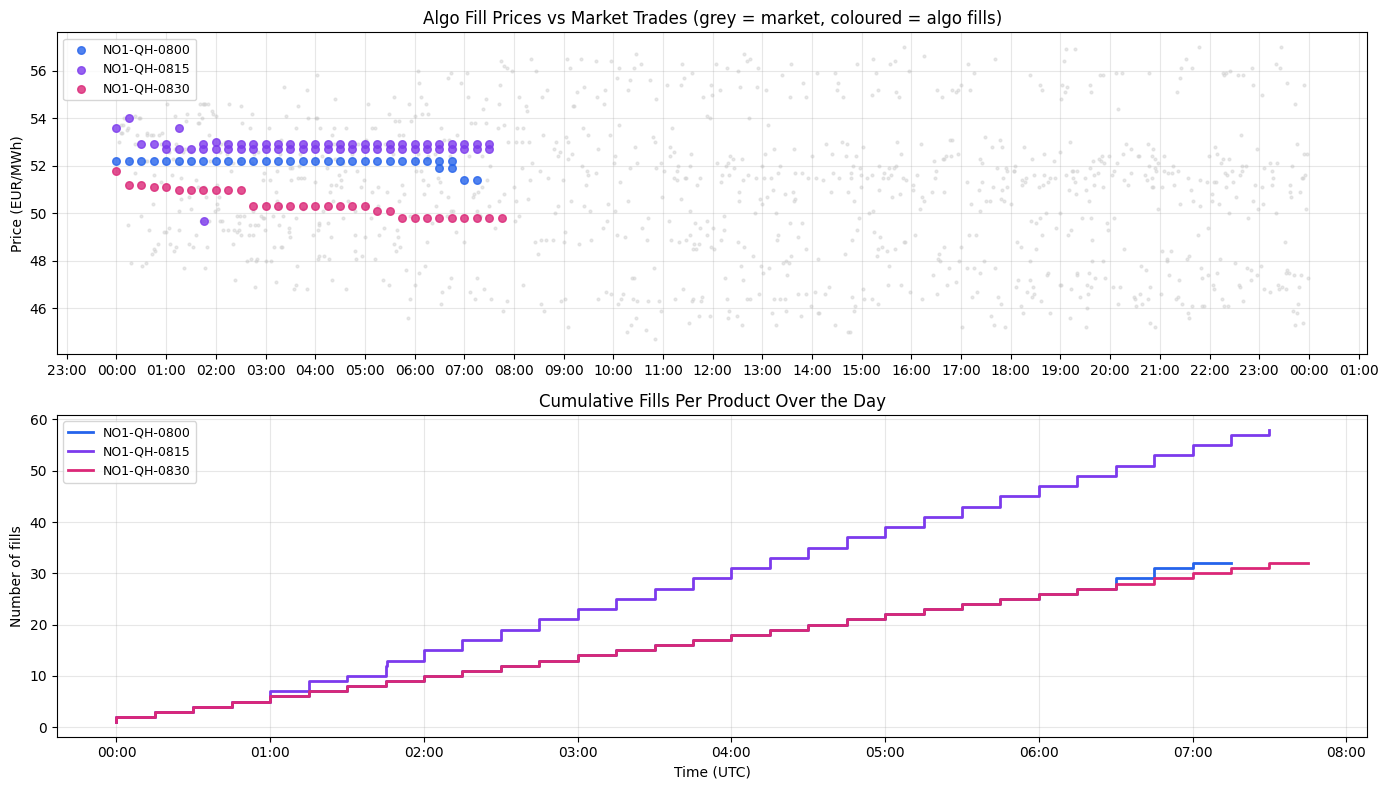


Fills per product:
             fills  total_mw
product_id                  
NO1-QH-0800     32      30.0
NO1-QH-0815     58      31.0
NO1-QH-0830     32      32.0


In [8]:
# Visualise fills: price over time, coloured by product

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

product_colors_fills = {
    "NO1-QH-0800": "#2563eb",
    "NO1-QH-0815": "#7c3aed",
    "NO1-QH-0830": "#db2777",
}

# Panel 1: fill price timeline
ax1 = axes[0]
for product_id, group in fills_df.groupby("product_id"):
    ax1.scatter(
        group["timestamp"], group["price"],
        c=product_colors_fills.get(product_id, "grey"),
        label=product_id, alpha=0.8, s=30, zorder=3,
    )

# Overlay the market trades for context
for product_id, group in idc_events[idc_events.event_type == "trade"].groupby("product_id"):
    ax1.scatter(
        group["timestamp"], group["price_eur_mwh"],
        c="lightgrey", s=4, alpha=0.5, zorder=1,
    )

ax1.set_title("Algo Fill Prices vs Market Trades (grey = market, coloured = algo fills)", fontsize=12)
ax1.set_ylabel("Price (EUR/MWh)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: cumulative fills per product
ax2 = axes[1]
for product_id, group in fills_df.groupby("product_id"):
    group_sorted = group.sort_values("timestamp")
    cumulative = range(1, len(group_sorted) + 1)
    ax2.step(
        group_sorted["timestamp"], list(cumulative),
        label=product_id,
        color=product_colors_fills.get(product_id, "grey"),
        linewidth=2,
    )

ax2.set_title("Cumulative Fills Per Product Over the Day", fontsize=12)
ax2.set_ylabel("Number of fills")
ax2.set_xlabel("Time (UTC)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFills per product:")
print(fills_df.groupby("product_id")["volume"].agg(["count", "sum"]).rename(columns={"count": "fills", "sum": "total_mw"}))

### 1.7 Gate Closure — A Key IDC Concept

Gate closure is the deadline after which no new orders can be submitted for a product. In Nord Pool IDC, gate closes **30 minutes before delivery start**:
- `NO1-QH-0800` (delivers 08:00–08:15): gate closes at **07:30 UTC**
- `NO1-QH-0815` (delivers 08:15–08:30): gate closes at **07:45 UTC**  
- `NO1-QH-0830` (delivers 08:30–08:45): gate closes at **08:00 UTC**

Any resting algo orders are automatically cancelled at gate closure and `on_gate_closure` is called. Let's verify that our algo saw gate closures for all three products:

In [9]:
algo = idc_engine._dispatcher._algo  # access the algo instance to inspect its state

print("Gate closures seen by the algo:")
for product_id in sorted(algo.gate_closures_seen):
    print(f"  {product_id}")

# Verify no fills happened after gate closure for any product
gate_closure_times = {
    "NO1-QH-0800": pd.Timestamp("2026-03-01 07:30:00", tz="UTC"),
    "NO1-QH-0815": pd.Timestamp("2026-03-01 07:45:00", tz="UTC"),
    "NO1-QH-0830": pd.Timestamp("2026-03-01 08:00:00", tz="UTC"),
}

print("\nFills after gate closure (should be 0 for each product):")
for product_id, gate_time in gate_closure_times.items():
    late_fills = fills_df[
        (fills_df["product_id"] == product_id) &
        (fills_df["timestamp"] >= gate_time)
    ]
    print(f"  {product_id}: {len(late_fills)} fills after {gate_time.strftime('%H:%M')} ✓")

print("\nLast fill per product (should be before gate closure):")
for product_id in sorted(gate_closure_times):
    product_fills = fills_df[fills_df["product_id"] == product_id]
    if not product_fills.empty:
        last_fill_time = product_fills["timestamp"].max()
        gate_time = gate_closure_times[product_id]
        ok = "✓" if last_fill_time < gate_time else "✗"
        print(f"  {product_id}: last fill at {last_fill_time.strftime('%H:%M')}, gate at {gate_time.strftime('%H:%M')} {ok}")

Gate closures seen by the algo:
  NO1-QH-0000
  NO1-QH-0015
  NO1-QH-0030
  NO1-QH-0045
  NO1-QH-0100
  NO1-QH-0115
  NO1-QH-0130
  NO1-QH-0145
  NO1-QH-0200
  NO1-QH-0215
  NO1-QH-0230
  NO1-QH-0245
  NO1-QH-0300
  NO1-QH-0315
  NO1-QH-0330
  NO1-QH-0345
  NO1-QH-0400
  NO1-QH-0415
  NO1-QH-0430
  NO1-QH-0445
  NO1-QH-0500
  NO1-QH-0515
  NO1-QH-0530
  NO1-QH-0545
  NO1-QH-0600
  NO1-QH-0615
  NO1-QH-0630
  NO1-QH-0645
  NO1-QH-0700
  NO1-QH-0715
  NO1-QH-0730
  NO1-QH-0745
  NO1-QH-0800
  NO1-QH-0815
  NO1-QH-0830
  NO1-QH-0845
  NO1-QH-0900
  NO1-QH-0915
  NO1-QH-0930
  NO1-QH-0945
  NO1-QH-1000
  NO1-QH-1015
  NO1-QH-1030
  NO1-QH-1045
  NO1-QH-1100
  NO1-QH-1115
  NO1-QH-1130
  NO1-QH-1145
  NO1-QH-1200
  NO1-QH-1215
  NO1-QH-1230
  NO1-QH-1245
  NO1-QH-1300
  NO1-QH-1315
  NO1-QH-1330
  NO1-QH-1345
  NO1-QH-1400
  NO1-QH-1415
  NO1-QH-1430
  NO1-QH-1445
  NO1-QH-1500
  NO1-QH-1515
  NO1-QH-1530
  NO1-QH-1545
  NO1-QH-1600
  NO1-QH-1615
  NO1-QH-1630
  NO1-QH-1645
  NO1-QH-1700
  

Gate closure is working correctly: no fills happen after the gate closes, and the algo received `on_gate_closure` for all three products.

---

## Part 2: The Equity Curve and Advanced Metrics

Total PnL tells you how much money the algo made in total. But it tells you nothing about *how* it made that money. Was it one lucky day and everything else was losses? Or was it steady consistent positive returns?

The **equity curve** answers these questions. It's the single most important chart in quantitative finance.

### 2.1 What Is an Equity Curve?

An equity curve is a time series of your total capital: `initial_capital + cumulative_PnL` at each point in time. If you start with €100,000:
- After day 1 with +€500 PnL → equity = €100,500
- After day 2 with −€200 PnL → equity = €100,300  
- After day 3 with +€800 PnL → equity = €101,100

A **good** equity curve goes up steadily with small dips. A **bad** one is volatile, has large drawdowns, or is trending down.

To get a meaningful equity curve across multiple days, let's run a DA backtest over the full month of March 2026:

In [10]:
from nexa_backtest.types import AuctionInfo


class MomentumAlgo(SimpleAlgo):
    """Buys more aggressively during morning/evening peaks, less at other times.

    This creates variation in fill prices relative to VWAP — some days will be
    profitable, some won't — which gives us an interesting equity curve to study.
    """

    def on_auction_open(self, ctx: TradingContext, auction: AuctionInfo) -> None:
        hour = ctx.now().hour

        # During 'peak' hours (morning and evening) buy 3 MW at a price that
        # will almost certainly fill (bid well above any expected clearing price).
        # During 'off-peak' hours buy 1 MW but at a tighter price that may not fill.
        if 6 <= hour <= 9 or 17 <= hour <= 20:
            order = Order.buy(auction.product_id, volume_mw=3.0, price_eur_mwh=80.0)
        else:
            order = Order.buy(auction.product_id, volume_mw=1.0, price_eur_mwh=42.0)

        ctx.place_order(order)


# Run a full month of DA backtesting
da_engine = BacktestEngine(
    algo=MomentumAlgo(),
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 31),
    products=["NO1_DA"],
    data_dir=DA_DATA_DIR,
    capital=Decimal("100000"),
)

print("Running DA backtest (full March 2026)...")
da_result = da_engine.run()
print("Done!\n")

print(da_result.summary())

Running DA backtest (full March 2026)...


Done!

  Backtest Results: 2026-03-01  to  2026-03-31  (31 days)
  Exchange: nordpool | Algo: MomentumAlgo

  Total PnL:            +12,317.40 EUR
  Market VWAP:               44.79 EUR/MWh
  Sharpe Ratio:             133.11
  Max Drawdown:             -0.00 EUR  (-0.0%)
  Profit Factor:    N/A (no losses)

  Trades:                    1,211
  Win Rate:                 100.0%
  Avg Trade PnL:            +10.17 EUR
  Best Trade:              +36.50 EUR  (NO1_20260310T2115Z 2026-03-09 13:00)
  Worst Trade:              +2.79 EUR  (NO1_20260326T1500Z 2026-03-25 13:00)

  Total Volume:            1,211.0 MW
  Initial Capital:      100,000.00 EUR
  Final Equity:         112,317.40 EUR

  Buys
    Fills:        1211
    Volume:         1211.0 MWh
    Avg Price:       34.62 EUR/MWh
    vs VWAP:        +10.17 EUR/MWh  (bought below VWAP ✓)
    EUR Alpha:   +12317.40 EUR
    Win Rate:      100.0%

  Total Alpha:   +12317.40 EUR
  Total Fills:    1211


### 2.2 The Equity Curve DataFrame

The `BacktestResult` object stores an equity snapshot after each trading day. Access it via `equity_curve_df()`:

In [11]:
eq_df = da_result.equity_curve_df()

print(f"Shape: {eq_df.shape}  (one row per day with trading activity)")
print(f"\nColumns: {list(eq_df.columns)}")
print(f"\nColumn meanings:")
print("  timestamp        — when the snapshot was recorded (DA: gate closure time)")
print("  realised_pnl     — cumulative PnL locked in by closed trades (EUR)")
print("  unrealised_pnl   — mark-to-market of open positions (0 for DA — DA settles immediately)")
print("  total_equity     — initial_capital + realised_pnl + unrealised_pnl")
print("  cash             — cash remaining after settled trades")
print("  net_position_mw  — total MW held across all products")
print()
eq_df.head(10)

Shape: (31, 6)  (one row per day with trading activity)

Columns: ['timestamp', 'realised_pnl', 'unrealised_pnl', 'total_equity', 'cash', 'net_position_mw']

Column meanings:
  timestamp        — when the snapshot was recorded (DA: gate closure time)
  realised_pnl     — cumulative PnL locked in by closed trades (EUR)
  unrealised_pnl   — mark-to-market of open positions (0 for DA — DA settles immediately)
  total_equity     — initial_capital + realised_pnl + unrealised_pnl
  cash             — cash remaining after settled trades
  net_position_mw  — total MW held across all products



,timestamp,realised_pnl,unrealised_pnl,total_equity,cash,net_position_mw
0,2026-02-28 13:00:00+00:00,366.815896,0.0,100366.815896,100366.815896,0.0
1,2026-03-01 13:00:00+00:00,746.425813,0.0,100746.425813,100746.425813,0.0
2,2026-03-02 13:00:00+00:00,1114.021224,0.0,101114.021224,101114.021224,0.0
3,2026-03-03 13:00:00+00:00,1480.659220,0.0,101480.659220,101480.659220,0.0
4,2026-03-04 13:00:00+00:00,1892.826710,0.0,101892.826710,101892.826710,0.0
5,2026-03-05 13:00:00+00:00,2323.418349,0.0,102323.418349,102323.418349,0.0
6,2026-03-06 13:00:00+00:00,2797.521149,0.0,102797.521149,102797.521149,0.0
7,2026-03-07 13:00:00+00:00,3164.997498,0.0,103164.997498,103164.997498,0.0
8,2026-03-08 13:00:00+00:00,3512.885033,0.0,103512.885033,103512.885033,0.0
9,2026-03-09 13:00:00+00:00,3968.239776,0.0,103968.239776,103968.239776,0.0


### 2.3 Plotting the Equity Curve

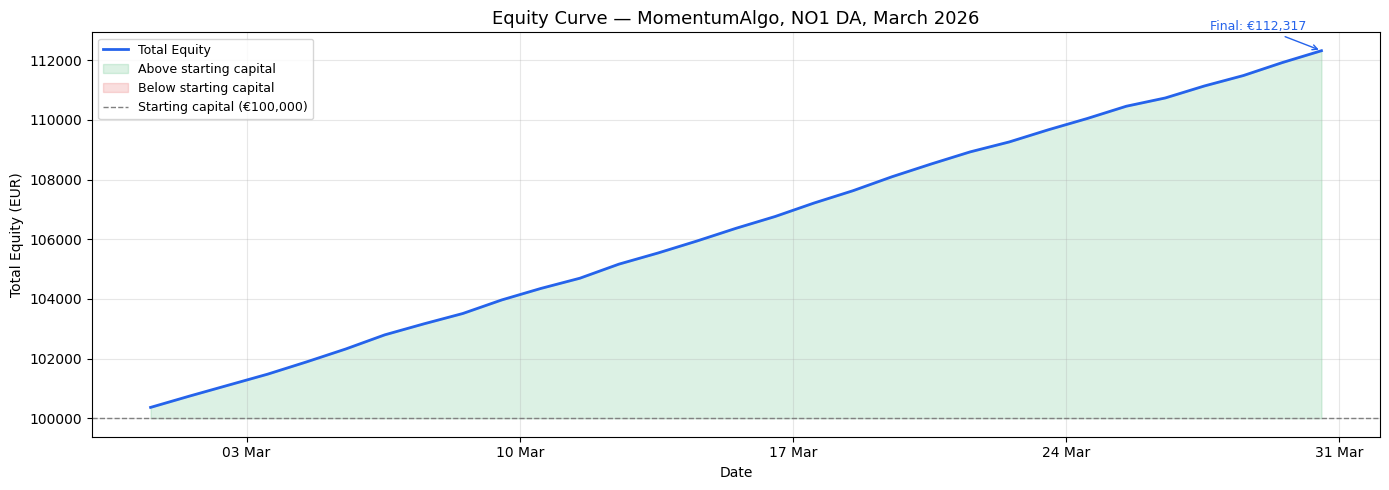

Starting capital: €100,000.00
Final equity:     €112,317.40
Net change:       €+12,317.40


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

# Equity curve line
ax.plot(eq_df["timestamp"], eq_df["total_equity"],
        color="#2563eb", linewidth=2, label="Total Equity")

# Shade the area under the equity curve
ax.fill_between(eq_df["timestamp"], float(da_result.initial_capital), eq_df["total_equity"],
                where=eq_df["total_equity"] >= float(da_result.initial_capital),
                alpha=0.15, color="#16a34a", label="Above starting capital")
ax.fill_between(eq_df["timestamp"], float(da_result.initial_capital), eq_df["total_equity"],
                where=eq_df["total_equity"] < float(da_result.initial_capital),
                alpha=0.15, color="#dc2626", label="Below starting capital")

# Starting capital reference line
ax.axhline(float(da_result.initial_capital), color="grey", linewidth=1.0,
           linestyle="--", label=f"Starting capital (€{float(da_result.initial_capital):,.0f})")

# Final equity annotation
final_equity = eq_df["total_equity"].iloc[-1]
ax.annotate(
    f"Final: €{final_equity:,.0f}",
    xy=(eq_df["timestamp"].iloc[-1], final_equity),
    xytext=(-80, 15), textcoords="offset points",
    fontsize=9, color="#2563eb",
    arrowprops=dict(arrowstyle="->", color="#2563eb", lw=1.0),
)

ax.set_title("Equity Curve — MomentumAlgo, NO1 DA, March 2026", fontsize=13)
ax.set_ylabel("Total Equity (EUR)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Starting capital: €{float(da_result.initial_capital):,.2f}")
print(f"Final equity:     €{final_equity:,.2f}")
print(f"Net change:       €{final_equity - float(da_result.initial_capital):+,.2f}")

### 2.4 Drawdown — The "Pain" Chart

**Maximum drawdown** is the largest peak-to-trough decline in equity. It measures how bad things got before they got better.

A strategy with a 30% max drawdown means: at some point, you were down 30% from your highest equity. Can you stomach that? Would you have stopped trading at -10%? If yes, the strategy's Sharpe ratio means nothing — you would have quit before it recovered.

The **drawdown chart** shows the running distance below the equity peak at every point in time:

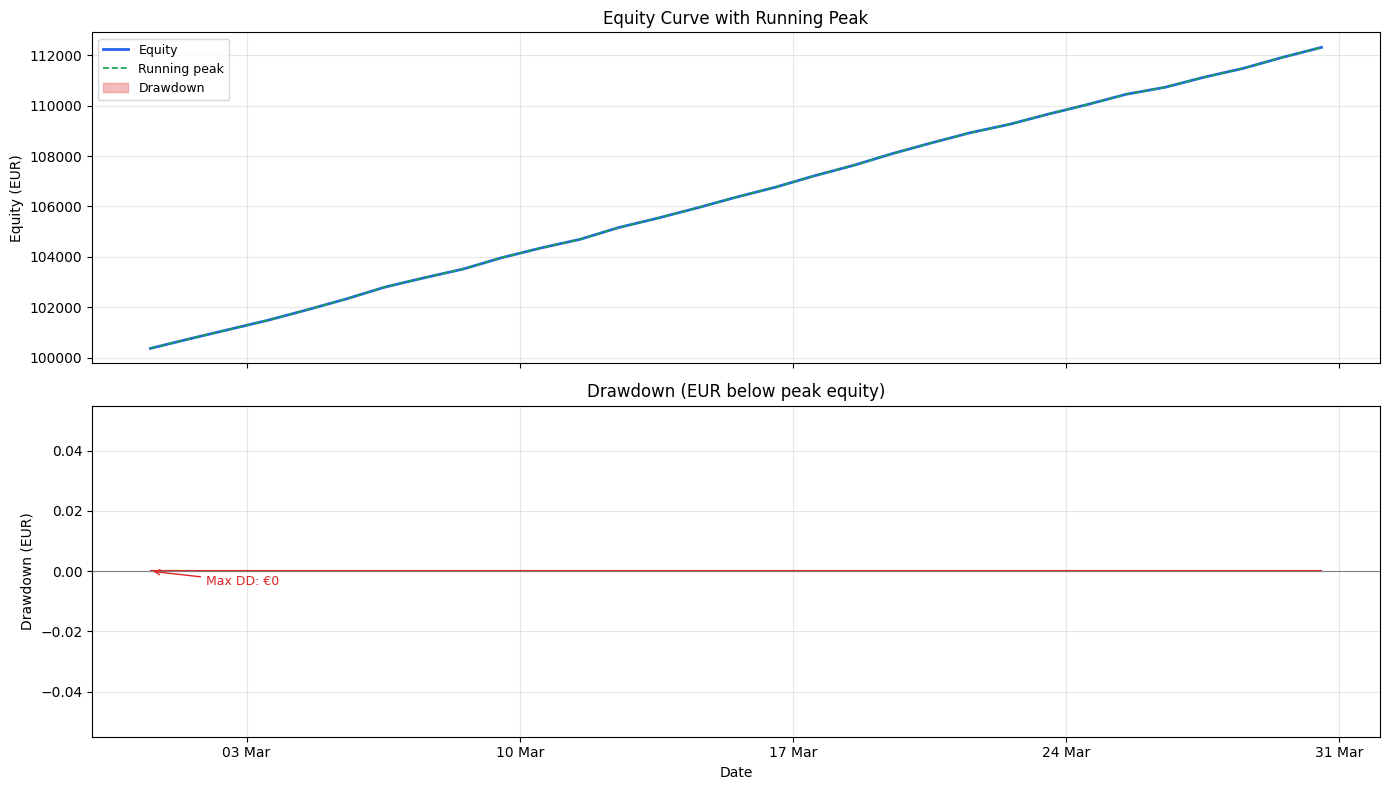

Max drawdown (EUR): €0.00
Max drawdown (%):   0.00%

Interpretation: at its worst point, the strategy was €0.00
(0.00%) below its previous peak.


In [13]:
# Calculate drawdown series
equity = eq_df["total_equity"].values
running_peak = np.maximum.accumulate(equity)
drawdown_eur = equity - running_peak          # negative when below peak
drawdown_pct = drawdown_eur / running_peak * 100  # as percentage

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: equity with running peak
ax1 = axes[0]
ax1.plot(eq_df["timestamp"], equity, color="#2563eb", linewidth=2, label="Equity")
ax1.plot(eq_df["timestamp"], running_peak, color="#16a34a", linewidth=1.2,
         linestyle="--", label="Running peak")
ax1.fill_between(eq_df["timestamp"], running_peak, equity,
                 where=equity < running_peak, alpha=0.3, color="#dc2626", label="Drawdown")
ax1.set_title("Equity Curve with Running Peak", fontsize=12)
ax1.set_ylabel("Equity (EUR)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: drawdown in EUR
ax2 = axes[1]
ax2.fill_between(eq_df["timestamp"], drawdown_eur, 0,
                 where=drawdown_eur < 0, alpha=0.7, color="#dc2626")
ax2.plot(eq_df["timestamp"], drawdown_eur, color="#dc2626", linewidth=1.5)
ax2.axhline(0, color="grey", linewidth=0.8)

# Mark the maximum drawdown point
max_dd_idx = np.argmin(drawdown_eur)
ax2.annotate(
    f"Max DD: €{drawdown_eur[max_dd_idx]:,.0f}",
    xy=(eq_df["timestamp"].iloc[max_dd_idx], drawdown_eur[max_dd_idx]),
    xytext=(40, -10), textcoords="offset points",
    fontsize=9, color="#dc2626",
    arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.0),
)

ax2.set_title("Drawdown (EUR below peak equity)", fontsize=12)
ax2.set_ylabel("Drawdown (EUR)")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max drawdown (EUR): €{float(da_result.max_drawdown):,.2f}")
print(f"Max drawdown (%):   {float(da_result.max_drawdown_pct)*100:.2f}%")
print(f"\nInterpretation: at its worst point, the strategy was €{float(da_result.max_drawdown):,.2f}")
print(f"({float(da_result.max_drawdown_pct)*100:.2f}%) below its previous peak.")

### 2.5 Sharpe Ratio — Return per Unit of Risk

The **Sharpe ratio** is the single most widely used performance metric in quantitative finance. It answers:

> *How much return are you getting per unit of risk you're taking?*

The formula is: `Sharpe = mean(daily_returns) / std(daily_returns) × √(annualisation_factor)`

Rough interpretation:
- **< 0**: Losing money — worse than risk-free
- **0 – 0.5**: Very poor (high volatility relative to returns)
- **0.5 – 1.0**: Acceptable (most passive strategies land here)
- **1.0 – 2.0**: Good (professional funds target this range)
- **> 2.0**: Excellent (rare; usually means there's a bug or look-ahead bias)

A negative Sharpe with positive total PnL is *possible* — it means the average day was slightly negative but one or two very good days dragged the total into profit. That's a fragile strategy.

Returns (% change per snapshot):
  Mean:   0.3757%
  StdDev: 0.0448%
  Min:    0.2515%
  Max:    0.4633%

Annualisation factor (daily DA snapshots): √252 = 15.8745

Sharpe (manual calculation):    133.1102
Sharpe (from BacktestResult):   133.1102
(slight difference due to exact timestamp-based annualisation in the engine)


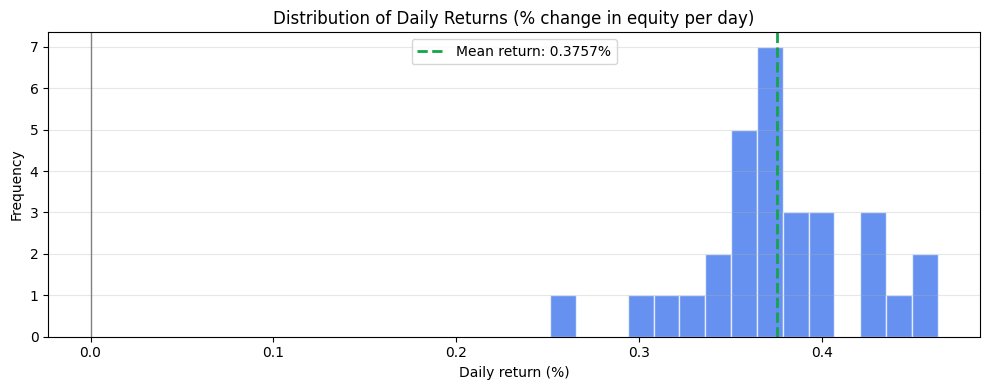

In [14]:
# Walk through the Sharpe calculation manually so you can see what's happening

equity_series = eq_df["total_equity"].values

# Step 1: percentage returns between consecutive snapshots
returns = np.diff(equity_series) / equity_series[:-1]
print(f"Returns (% change per snapshot):")
print(f"  Mean:   {np.mean(returns)*100:.4f}%")
print(f"  StdDev: {np.std(returns, ddof=1)*100:.4f}%")
print(f"  Min:    {np.min(returns)*100:.4f}%")
print(f"  Max:    {np.max(returns)*100:.4f}%")

# Step 2: annualisation factor
# Our snapshots are ~daily (DA gate closure = 1 snapshot/day).
# Annualisation: √(252 trading days per year)
annualisation = np.sqrt(252.0)
print(f"\nAnnualisation factor (daily DA snapshots): √252 = {annualisation:.4f}")

# Step 3: Sharpe ratio
sharpe_manual = (np.mean(returns) / np.std(returns, ddof=1)) * annualisation
print(f"\nSharpe (manual calculation):    {sharpe_manual:.4f}")
print(f"Sharpe (from BacktestResult):   {float(da_result.sharpe_ratio):.4f}")
print("(slight difference due to exact timestamp-based annualisation in the engine)")

# Visualise the return distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(returns * 100, bins=15, color="#2563eb", alpha=0.7, edgecolor="white")
ax.axvline(np.mean(returns) * 100, color="#16a34a", linewidth=2, linestyle="--",
           label=f"Mean return: {np.mean(returns)*100:.4f}%")
ax.axvline(0, color="grey", linewidth=1.0, linestyle="-")
ax.set_title("Distribution of Daily Returns (% change in equity per day)", fontsize=12)
ax.set_xlabel("Daily return (%)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 2.6 The Full Metrics Dashboard

In [15]:
# All advanced metrics from BacktestResult in one place

r = da_result
p = r.pnl

print("=" * 55)
print(" ADVANCED METRICS REFERENCE")
print("=" * 55)

# --- Performance ---
total_pnl = float(p.total_alpha_eur)
final_equity = float(r.initial_capital) + total_pnl
print(f"\n  Performance")
print(f"    Initial capital:    €{float(r.initial_capital):>12,.2f}")
print(f"    Final equity:       €{final_equity:>12,.2f}")
print(f"    Total PnL (VWAP-α): €{total_pnl:>+12,.2f}")
print(f"    Market VWAP:         {float(p.market_vwap):>12.4f} EUR/MWh")

# --- Risk ---
print(f"\n  Risk")
sharpe_str = f"{float(r.sharpe_ratio):.4f}" if r.sharpe_ratio is not None else "N/A"
print(f"    Sharpe ratio:        {sharpe_str:>12}")
print(f"    Max drawdown:       €{float(r.max_drawdown):>12,.2f}")
print(f"    Max drawdown (%):    {float(r.max_drawdown_pct)*100:>11.2f}%")

# --- Trade Statistics ---
print(f"\n  Trade Statistics")
pf_str = f"{float(r.profit_factor):.4f}" if r.profit_factor is not None else "N/A (no losses)"
print(f"    Total fills:         {len(r.fills):>12,d}")
print(f"    Avg fill PnL:       €{float(r.avg_trade_pnl):>+12,.4f}")
print(f"    Profit factor:       {pf_str:>12}")
print(f"    Duration:            {r.duration_days:>12} days")

# --- Best and Worst fills ---
from nexa_backtest.analysis.metrics import compute_fill_pnl
if r.best_trade:
    bt_pnl = compute_fill_pnl(r.best_trade, p.market_vwap)
    wt_pnl = compute_fill_pnl(r.worst_trade, p.market_vwap)
    print(f"\n  Best / Worst Fills")
    print(f"    Best fill:          €{float(bt_pnl):>+12,.2f}  ({r.best_trade.product_id} {r.best_trade.timestamp.strftime('%Y-%m-%d %H:%M')})")
    print(f"    Worst fill:         €{float(wt_pnl):>+12,.2f}  ({r.worst_trade.product_id} {r.worst_trade.timestamp.strftime('%Y-%m-%d %H:%M')})")

print(f"\n{'='*55}")

print(f"""
Metric glossary:
  Total PnL (VWAP-α)  How much better/worse the algo executed vs the market VWAP.
                       Positive = you traded better than average.
  Sharpe ratio         Return-to-risk ratio. Higher is better; > 1.0 is good.
  Max drawdown         Worst peak-to-trough decline. Smaller = more stable.
  Profit factor        Total winning PnL / total losing PnL. > 1.0 = net winner.
  Avg fill PnL         Mean VWAP-relative PnL per fill. Sign matters more than magnitude.
""")

 ADVANCED METRICS REFERENCE

  Performance
    Initial capital:    €  100,000.00
    Final equity:       €  112,317.40
    Total PnL (VWAP-α): €  +12,317.40
    Market VWAP:              44.7894 EUR/MWh

  Risk
    Sharpe ratio:            133.1102
    Max drawdown:       €        0.00
    Max drawdown (%):           0.00%

  Trade Statistics
    Total fills:                1,211
    Avg fill PnL:       €    +10.1713
    Profit factor:       N/A (no losses)
    Duration:                      31 days

  Best / Worst Fills
    Best fill:          €      +36.50  (NO1_20260310T2115Z 2026-03-09 13:00)
    Worst fill:         €       +2.79  (NO1_20260326T1500Z 2026-03-25 13:00)


Metric glossary:
  Total PnL (VWAP-α)  How much better/worse the algo executed vs the market VWAP.
                       Positive = you traded better than average.
  Sharpe ratio         Return-to-risk ratio. Higher is better; > 1.0 is good.
  Max drawdown         Worst peak-to-trough decline. Smaller = more stable

### 2.7 Daily PnL Breakdown

The equity curve shows the cumulative picture. The **daily PnL chart** shows which individual days were wins and which were losses — useful for spotting patterns (e.g., "this algo always loses on Mondays").

Daily PnL DataFrame columns: ['date', 'pnl', 'volume_mw', 'trade_count', 'vwap_edge']
Rows: 31 (one per trading day)



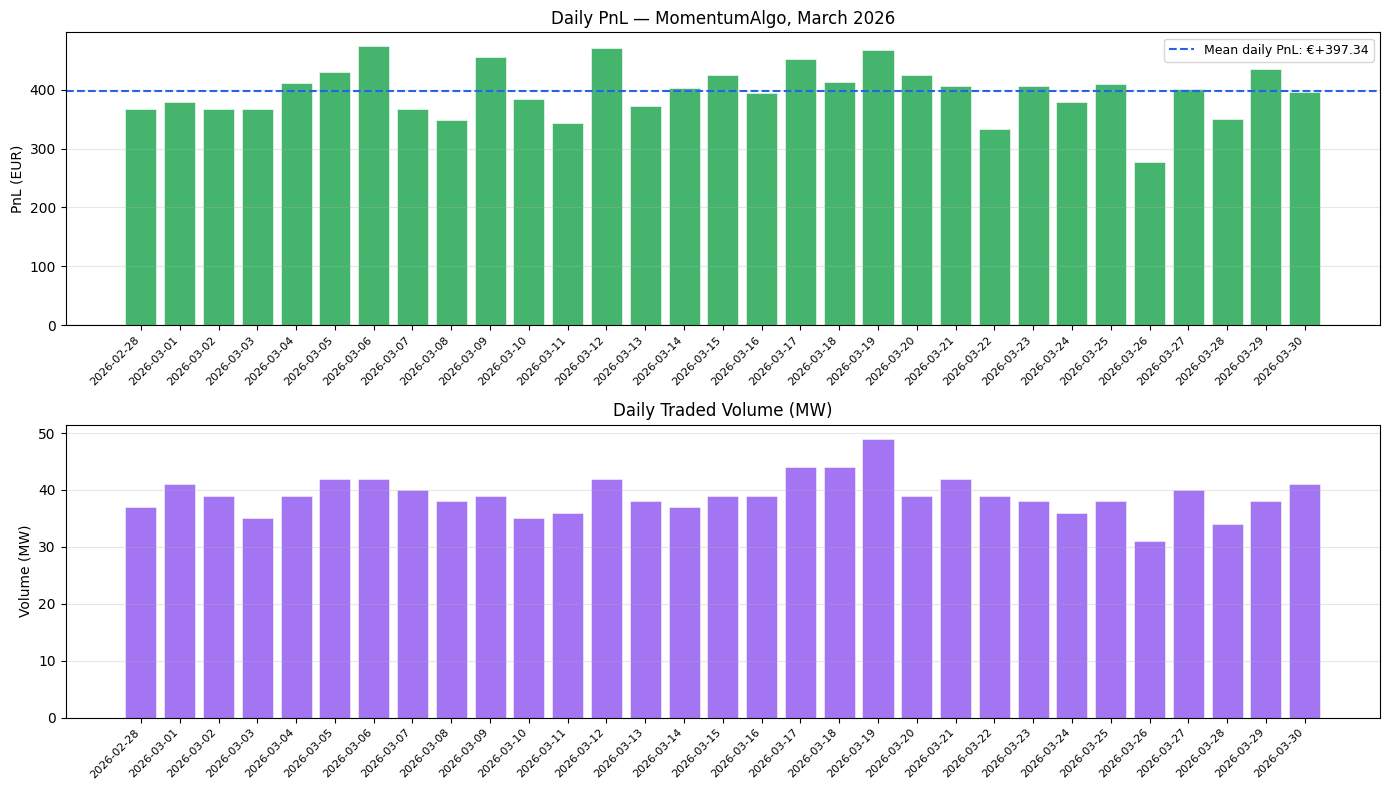

Winning days: 31  |  Losing days: 0
Win rate (by day): 100.0%

Top 5 best days:
      date        pnl  trade_count  vwap_edge
2026-03-06 474.102800           42  11.288162
2026-03-12 471.427782           42  11.224471
2026-03-19 468.212601           49   9.555359
2026-03-09 455.354743           39  11.675763
2026-03-17 452.868078           44  10.292456

Top 5 worst days:
      date        pnl  trade_count  vwap_edge
2026-03-26 277.777303           31   8.960558
2026-03-22 332.614296           39   8.528572
2026-03-11 343.071001           36   9.529750
2026-03-08 347.887535           38   9.154935
2026-03-28 349.727200           34  10.286094


In [16]:
daily_df = da_result.daily_pnl_df()
print(f"Daily PnL DataFrame columns: {list(daily_df.columns)}")
print(f"Rows: {len(daily_df)} (one per trading day)")
print()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: daily PnL bar chart
ax1 = axes[0]
colors_daily = ["#16a34a" if v >= 0 else "#dc2626" for v in daily_df["pnl"]]
bars = ax1.bar(
    range(len(daily_df)), daily_df["pnl"],
    color=colors_daily, alpha=0.8, edgecolor="white", linewidth=0.5,
)
ax1.axhline(0, color="grey", linewidth=0.8)
ax1.axhline(float(daily_df["pnl"].mean()), color="#2563eb", linewidth=1.5,
            linestyle="--", label=f"Mean daily PnL: €{float(daily_df['pnl'].mean()):+.2f}")
ax1.set_title("Daily PnL — MomentumAlgo, March 2026", fontsize=12)
ax1.set_ylabel("PnL (EUR)")
ax1.set_xticks(range(len(daily_df)))
ax1.set_xticklabels([str(d) for d in daily_df["date"]], rotation=45, ha="right", fontsize=8)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis="y")

# Panel 2: volume traded per day
ax2 = axes[1]
ax2.bar(range(len(daily_df)), daily_df["volume_mw"],
        color="#7c3aed", alpha=0.7, edgecolor="white", linewidth=0.5)
ax2.set_title("Daily Traded Volume (MW)", fontsize=12)
ax2.set_ylabel("Volume (MW)")
ax2.set_xticks(range(len(daily_df)))
ax2.set_xticklabels([str(d) for d in daily_df["date"]], rotation=45, ha="right", fontsize=8)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Summary stats
winning_days = (daily_df["pnl"] > 0).sum()
losing_days  = (daily_df["pnl"] < 0).sum()
print(f"Winning days: {winning_days}  |  Losing days: {losing_days}")
print(f"Win rate (by day): {winning_days / len(daily_df):.1%}")
print(f"\nTop 5 best days:")
print(daily_df.nlargest(5, "pnl")[["date", "pnl", "trade_count", "vwap_edge"]].to_string(index=False))
print(f"\nTop 5 worst days:")
print(daily_df.nsmallest(5, "pnl")[["date", "pnl", "trade_count", "vwap_edge"]].to_string(index=False))

### 2.8 The Trades DataFrame

Every individual fill is available via `trades_df()`. This lets you do your own analysis — slicing by product, by hour of day, by price level:

Shape: (1211, 6)  (one row per fill)
Columns: ['timestamp', 'product_id', 'side', 'price', 'volume', 'order_id']



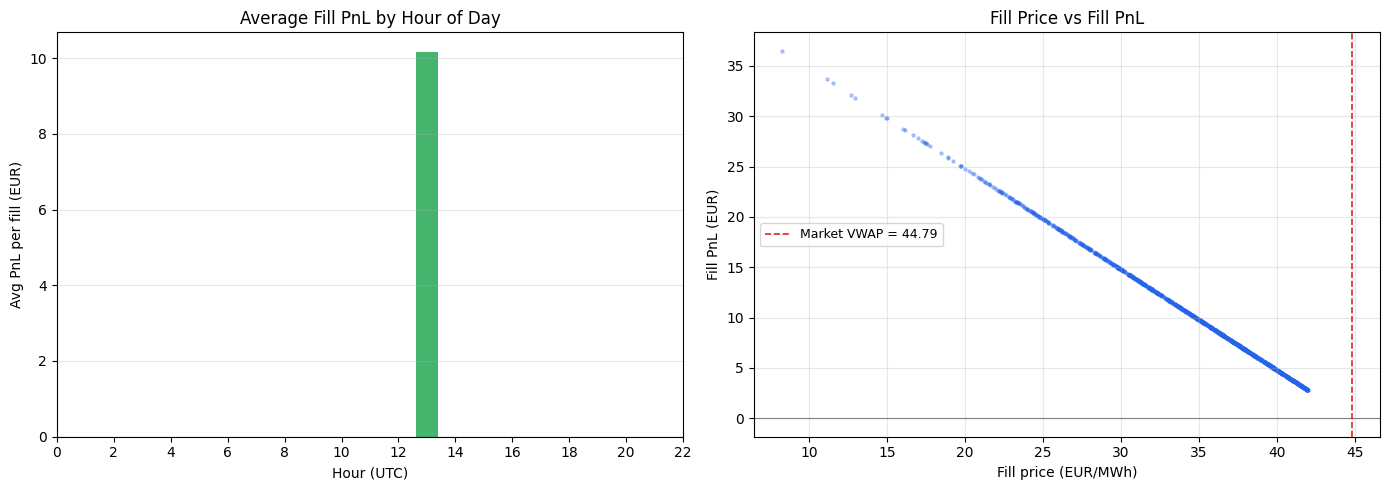

Market VWAP: 44.7894 EUR/MWh
Fills below VWAP (profitable buys): 1211
Fills above VWAP (costly buys):     0


In [17]:
trades_df = da_result.trades_df()
print(f"Shape: {trades_df.shape}  (one row per fill)")
print(f"Columns: {list(trades_df.columns)}")
print()

# Add hour-of-day and compute VWAP-relative PnL per fill
market_vwap = float(da_result.pnl.market_vwap)
trades_df["hour"] = trades_df["timestamp"].dt.hour
# For buys: (market_vwap - fill_price) * volume → positive if we bought below VWAP
trades_df["fill_pnl"] = (market_vwap - trades_df["price"]) * trades_df["volume"]

# --- Visualise: average PnL by hour of day ---
hourly_pnl = trades_df.groupby("hour")["fill_pnl"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
bar_colors = ["#16a34a" if v >= 0 else "#dc2626" for v in hourly_pnl.values]
ax1.bar(hourly_pnl.index, hourly_pnl.values, color=bar_colors, alpha=0.8, width=0.8)
ax1.axhline(0, color="grey", linewidth=0.8)
ax1.set_title("Average Fill PnL by Hour of Day", fontsize=12)
ax1.set_xlabel("Hour (UTC)")
ax1.set_ylabel("Avg PnL per fill (EUR)")
ax1.set_xticks(range(0, 24, 2))
ax1.grid(True, alpha=0.3, axis="y")

# --- Fill price vs market VWAP ---
ax2 = axes[1]
ax2.scatter(trades_df["price"], trades_df["fill_pnl"],
            alpha=0.3, s=5, color="#2563eb")
ax2.axhline(0, color="grey", linewidth=0.8)
ax2.axvline(market_vwap, color="#dc2626", linewidth=1.2, linestyle="--",
            label=f"Market VWAP = {market_vwap:.2f}")
ax2.set_title("Fill Price vs Fill PnL", fontsize=12)
ax2.set_xlabel("Fill price (EUR/MWh)")
ax2.set_ylabel("Fill PnL (EUR)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Market VWAP: {market_vwap:.4f} EUR/MWh")
print(f"Fills below VWAP (profitable buys): {(trades_df['price'] < market_vwap).sum()}")
print(f"Fills above VWAP (costly buys):     {(trades_df['price'] > market_vwap).sum()}")

### 2.9 Exporting Results

`BacktestResult` has three export formats:

| Method | Output | Use case |
|---|---|---|
| `to_html(path)` | Self-contained HTML file with Plotly charts | Share with colleagues, present in a browser |
| `to_json(path)` | JSON file with all metrics and data | Store results, feed into downstream systems |
| `to_parquet(path)` | Directory of Parquet files | Large datasets, efficient loading into pandas/dask |

In [18]:
import json, tempfile
from pathlib import Path

tmp = Path(tempfile.mkdtemp())

# --- JSON export ---
json_path = tmp / "backtest_result.json"
da_result.to_json(str(json_path))

# Read it back and inspect structure
with open(json_path) as f:
    result_json = json.load(f)

print("JSON export structure (top-level keys):")
for key, value in result_json.items():
    if isinstance(value, list):
        print(f"  {key}: list of {len(value)} items")
    else:
        print(f"  {key}: {value!r}")

print(f"\nFile size: {json_path.stat().st_size:,} bytes")

JSON export structure (top-level keys):
  algo_name: 'MomentumAlgo'
  exchange: 'nordpool'
  start_date: '2026-03-01'
  end_date: '2026-03-31'
  duration_days: 31
  initial_capital: '100000'
  total_pnl: '12317.4044533767717760'
  market_vwap: '44.789382'
  sharpe_ratio: '133.110239'
  max_drawdown: '0'
  max_drawdown_pct: '0'
  profit_factor: None
  avg_trade_pnl: '10.17126709609972896449215524'
  trade_count: 1211
  equity_curve: list of 31 items
  trades: list of 1211 items

File size: 299,431 bytes


In [19]:
# --- Parquet export ---
parquet_dir = tmp / "parquet_output"
da_result.to_parquet(str(parquet_dir))

print("Parquet output directory contents:")
for f in sorted(parquet_dir.iterdir()):
    print(f"  {f.name:30s}  {f.stat().st_size:>8,} bytes")

# Read back the equity curve parquet and verify it matches the DataFrame
eq_from_parquet = pd.read_parquet(parquet_dir / "equity_curve.parquet")
print(f"\nEquity curve from Parquet: {len(eq_from_parquet)} rows")
print(f"Matches equity_curve_df(): {len(eq_from_parquet) == len(da_result.equity_curve_df())} ✓")

Parquet output directory contents:
  daily_pnl.parquet                  2,439 bytes
  equity_curve.parquet               3,093 bytes
  metadata.json                        424 bytes
  trades.parquet                    65,943 bytes

Equity curve from Parquet: 31 rows
Matches equity_curve_df(): True ✓


In [20]:
# --- HTML report ---
# This generates a self-contained HTML file with interactive Plotly charts
# styled with the Phase Nexa colour palette.

html_path = tmp / "report.html"
da_result.to_html(str(html_path))

html_size = html_path.stat().st_size
print(f"HTML report generated: {html_path}")
print(f"File size: {html_size:,} bytes  ({html_size // 1024:,} KB)")
print("\nThe report is self-contained — open it in any browser.")
print("It includes: equity curve, drawdown chart, daily PnL, VWAP edge, trade distribution,")
print("summary metrics table, top 10 best/worst trades, and a daily breakdown table.")

# Quick sanity check: the HTML contains our algo name
html_content = html_path.read_text(encoding="utf-8")
assert "MomentumAlgo" in html_content, "HTML should contain the algo name"
print(f"\nSanity check: algo name found in HTML ✓")

HTML report generated: /var/folders/t7/zj98q0q10hjdswg08sc9xsl80000gp/T/tmpvbv8a3w2/report.html
File size: 19,177 bytes  (18 KB)

The report is self-contained — open it in any browser.
It includes: equity curve, drawdown chart, daily PnL, VWAP edge, trade distribution,
summary metrics table, top 10 best/worst trades, and a daily breakdown table.

Sanity check: algo name found in HTML ✓


---

## Summary

### Part 1: IDC Backtesting

| Concept | What you learned |
|---|---|
| IDC vs DA | DA: one clearing price at a deadline. IDC: live order book, continuous matching |
| IDC event data | Streams of `new`, `cancel`, `trade` events that reconstruct the order book |
| Matching rules | Aggressive orders fill at the resting order's price. Passive orders rest until hit |
| `on_bar` hook | Called every 15 minutes — the main decision point for IDC algos |
| `get_best_ask/bid` | Read the current historical order book state |
| `time_to_gate_closure` | Prevents placing orders into a closing market |
| Gate closure | Automatically cancels resting orders and fires `on_gate_closure` |

### Part 2: Advanced Metrics

| Metric | What it tells you |
|---|---|
| **Equity curve** | Total capital over time — the complete picture of strategy performance |
| **Drawdown** | How far below the peak equity was at its worst — the "pain" chart |
| **Sharpe ratio** | Return per unit of risk. > 1.0 is good, > 2.0 is rare and suspicious |
| **Max drawdown** | Worst peak-to-trough decline. If you can't stomach it, the Sharpe is meaningless |
| **Profit factor** | Total wins / total losses. > 1.0 means you're net positive |
| **Daily PnL chart** | Which individual days won/lost — spot patterns and outliers |

### Key access methods on `BacktestResult`

```python
result.summary()          # → str, human-readable text summary
result.equity_curve_df()  # → pd.DataFrame, equity curve time series
result.trades_df()        # → pd.DataFrame, all fills
result.daily_pnl_df()     # → pd.DataFrame, per-day aggregation
result.daily_pnl()        # → list[DailyPnL], typed objects
result.to_html(path)      # → write HTML report with charts
result.to_json(path)      # → write JSON export
result.to_parquet(path)   # → write directory of Parquet files

# Direct attribute access:
result.sharpe_ratio       # Decimal | None
result.max_drawdown       # Decimal
result.max_drawdown_pct   # Decimal (fraction, not percentage)
result.profit_factor      # Decimal | None
result.equity_curve       # tuple[EquitySnapshot, ...]
result.best_trade         # Fill | None
result.worst_trade        # Fill | None
```

### What's next?

- **Signals** — wire in external data (wind forecasts, gas prices) to drive IDC order placement
- **Mixed DA + IDC** — run both engines simultaneously with a shared simulated clock
- **Position sizing** — use `ctx.get_position()` to avoid over-trading a single product
- **HTML report** — open the generated `report.html` to see all charts in an interactive format